In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    NaiveBayes,
    OneVsRest
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import os
import shutil

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [52]:
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.max_rows', None)     # Display all rows
pd.set_option('display.max_colwidth', None) # Remove column width limitation

In [53]:
file_name = "mazra3ti_dataset.csv"

df = pd.read_csv(file_name, parse_dates=["planting_date", "harvest_date", "sale_date"])
df["pest_indicator"] = df["pest_indicator"].replace({0: False, 1: True}).astype(bool)

df.head()

,record_id,crop_name,planting_date,harvest_date,season,area_size,quantity_sold,inventory_remaining,unit_price,total_sales,total_expenses,fertilizer_used,water_used,actual_yield,profit,sale_date,sale_gap_days,market_location,farm_location,region_type,distance_to_market,transport_cost,customer_type,market_price,temperature,humidity,rainfall,wind_speed,pest_indicator,water_efficiency,fertilizer_efficiency,demand_score,demand_level,supply_score,supply_level,sufficiency_status
0,1,Peach,2023-03-01,2023-07-24,Spring,109.56,170.90,17.95,3.752,641.22,198.70,34.50,784.22,188.85,442.52,2023-08-20,27,Maan,Ajloun,Rural,193.04,3.04,Trader,3.806,21.2,64.0,13.2,8.2,False,0.2408,5.4747,0.1947,Low,0.3808,Medium,Surplus
1,2,Zucchini,2022-03-11,2022-05-22,Spring,38.22,56.23,8.22,1.462,82.21,68.11,12.82,338.63,64.45,14.10,2022-05-26,4,Balqa,Maan,Rural,105.31,2.81,Local Market,1.566,23.6,60.4,36.5,10.9,False,0.1903,5.0273,0.5495,Medium,0.2042,Low,Shortage
2,3,Eggplant,2023-06-06,2023-09-27,Summer,37.18,63.94,4.20,1.461,93.45,74.47,8.78,365.27,68.15,18.99,2023-10-25,28,Irbid,Madaba,Urban,120.96,1.36,Local Market,1.447,25.6,31.7,3.3,3.0,False,0.1866,7.7613,0.2333,Low,0.2524,Low,Balanced
3,4,Beans,2020-04-08,2020-06-19,Spring,39.60,37.39,1.54,2.946,110.15,100.97,16.79,361.64,38.93,9.19,2020-06-22,3,Tafilah,Ajloun,Rural,213.64,3.40,Export,3.120,28.4,42.2,33.3,8.0,False,0.1077,2.3186,0.8411,High,0.1586,Low,Shortage
4,5,Lentils,2025-11-04,2026-03-13,Winter,56.67,8.59,0.38,2.543,21.83,87.84,15.06,542.06,8.97,-66.01,2026-04-04,22,Maan,Aqaba,Desert,31.36,0.36,Trader,2.516,31.7,34.3,5.3,16.8,False,0.0165,0.5955,0.3212,Low,0.1722,Low,Shortage


In [54]:
spark = SparkSession.builder.appName("Mazra3tiSpark").getOrCreate()

spark_df = spark.createDataFrame(df)

spark_df.printSchema()
spark_df.show(5)

print("Number of rows:", spark_df.count())
print("Number of columns:", len(spark_df.columns))

root
 |-- record_id: long (nullable = true)
 |-- crop_name: string (nullable = true)
 |-- planting_date: timestamp (nullable = true)
 |-- harvest_date: timestamp (nullable = true)
 |-- season: string (nullable = true)
 |-- area_size: double (nullable = true)
 |-- quantity_sold: double (nullable = true)
 |-- inventory_remaining: double (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- total_sales: double (nullable = true)
 |-- total_expenses: double (nullable = true)
 |-- fertilizer_used: double (nullable = true)
 |-- water_used: double (nullable = true)
 |-- actual_yield: double (nullable = true)
 |-- profit: double (nullable = true)
 |-- sale_date: timestamp (nullable = true)
 |-- sale_gap_days: long (nullable = true)
 |-- market_location: string (nullable = true)
 |-- farm_location: string (nullable = true)
 |-- region_type: string (nullable = true)
 |-- distance_to_market: double (nullable = true)
 |-- transport_cost: double (nullable = true)
 |-- customer_type: strin

In [55]:
target = "demand_level"

selected_raw_cols = [
    "crop_name",
    "sale_date",
    "market_location",
    "sale_gap_days",
    "sufficiency_status",
    "supply_score",
    "market_price",
    "temperature",
    "humidity",
    "rainfall",
    "wind_speed",
    "demand_level"
]

model_df = spark_df.select(*selected_raw_cols)

label_indexer = StringIndexer(
    inputCol=target,
    outputCol="label",
    handleInvalid="error"
)

print("Columns used for modeling:")
print(model_df.columns)
print("Number of modeling columns:", len(model_df.columns))

Columns used for modeling:
['crop_name', 'sale_date', 'market_location', 'sale_gap_days', 'sufficiency_status', 'supply_score', 'market_price', 'temperature', 'humidity', 'rainfall', 'wind_speed', 'demand_level']
Number of modeling columns: 12


In [56]:
model_df = (
    model_df
    .withColumn("sale_year", F.year("sale_date"))
    .withColumn("sale_month", F.month("sale_date"))
    .withColumn("sale_day", F.dayofmonth("sale_date"))
    .drop("sale_date")
)

model_df.show(5)
print("Total columns after date feature extraction:", len(model_df.columns))
print("Columns after date feature extraction:")
print(model_df.columns)

+---------+---------------+-------------+------------------+------------+------------+-----------+--------+--------+----------+------------+---------+----------+--------+
|crop_name|market_location|sale_gap_days|sufficiency_status|supply_score|market_price|temperature|humidity|rainfall|wind_speed|demand_level|sale_year|sale_month|sale_day|
+---------+---------------+-------------+------------------+------------+------------+-----------+--------+--------+----------+------------+---------+----------+--------+
|    Peach|           Maan|           27|           Surplus|      0.3808|       3.806|       21.2|    64.0|    13.2|       8.2|         Low|     2023|         8|      20|
| Zucchini|          Balqa|            4|          Shortage|      0.2042|       1.566|       23.6|    60.4|    36.5|      10.9|      Medium|     2022|         5|      26|
| Eggplant|          Irbid|           28|          Balanced|      0.2524|       1.447|       25.6|    31.7|     3.3|       3.0|         Low|     

In [57]:
categorical_cols = [
    "crop_name",
    "market_location",
    "sufficiency_status"
]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe")
    for col in categorical_cols
]

In [58]:
encoded_cols = [f"{col}_ohe" for col in categorical_cols]

numeric_cols = [
    col for col in model_df.columns
    if col not in categorical_cols + [target]
]

feature_cols = numeric_cols + encoded_cols

print("Numeric columns:")
print(numeric_cols)
print()

print("Encoded categorical columns:")
print(encoded_cols)
print()

print("Total feature columns:", len(feature_cols))

Numeric columns:
['sale_gap_days', 'supply_score', 'market_price', 'temperature', 'humidity', 'rainfall', 'wind_speed', 'sale_year', 'sale_month', 'sale_day']

Encoded categorical columns:
['crop_name_ohe', 'market_location_ohe', 'sufficiency_status_ohe']

Total feature columns: 13


In [59]:
crops = [row.crop_name for row in spark_df.select("crop_name").distinct().collect()]
print(crops)
print(len(crops))

['Chickpeas', 'Orange', 'Beans', 'Peach', 'Banana', 'Broccoli', 'Carrot', 'Cabbage', 'Peas', 'Melon', 'Fava Beans', 'Lentils', 'Potato', 'Grapes', 'Strawberry', 'Wheat', 'Lemon', 'Onion', 'Dates', 'Olives', 'Spinach', 'Garlic', 'Rice', 'Watermelon', 'Cucumber', 'Eggplant', 'Apricot', 'Apple', 'Pomegranate', 'Corn', 'Barley', 'Tomato', 'Lettuce', 'Zucchini', 'Bell Pepper']
35


In [60]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 77854
Test rows: 19322


In [61]:
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

In [62]:
def train_and_evaluate(model, model_name):
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

    pipeline = Pipeline(
        stages=[label_indexer] + indexers + encoders + [assembler, model]
    )

    fitted_model = pipeline.fit(train_df)
    predictions = fitted_model.transform(test_df)

    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    print(model_name)
    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print("-" * 40)

    return fitted_model, predictions, acc, f1, precision, recall

In [63]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
lr_model, lr_pred, lr_acc, lr_f1, lr_prec, lr_rec = train_and_evaluate(lr, "Logistic Regression")

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
dt_model, dt_pred, dt_acc, dt_f1, dt_prec, dt_rec = train_and_evaluate(dt, "Decision Tree")

rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_model, rf_pred, rf_acc, rf_f1, rf_prec, rf_rec = train_and_evaluate(rf, "Random Forest")

nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model, nb_pred, nb_acc, nb_f1, nb_prec, nb_rec = train_and_evaluate(nb, "Naive Bayes")

ovr = OneVsRest(classifier=LogisticRegression(featuresCol="features", labelCol="label"))
ovr_model, ovr_pred, ovr_acc, ovr_f1, ovr_prec, ovr_rec = train_and_evaluate(ovr, "OneVsRest + Logistic Regression")

Logistic Regression
Accuracy  : 0.8375
F1 Score  : 0.8355
Precision : 0.8371
Recall    : 0.8375
----------------------------------------
Decision Tree
Accuracy  : 0.7852
F1 Score  : 0.7567
Precision : 0.7822
Recall    : 0.7852
----------------------------------------
Random Forest
Accuracy  : 0.7370
F1 Score  : 0.6892
Precision : 0.6781
Recall    : 0.7370
----------------------------------------
Naive Bayes
Accuracy  : 0.6695
F1 Score  : 0.6746
Precision : 0.7055
Recall    : 0.6695
----------------------------------------
OneVsRest + Logistic Regression
Accuracy  : 0.8240
F1 Score  : 0.8154
Precision : 0.8283
Recall    : 0.8240
----------------------------------------


In [64]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "OneVsRest + Logistic Regression"
    ],
    "Accuracy": [lr_acc, dt_acc, rf_acc, nb_acc, ovr_acc],
    "F1": [lr_f1, dt_f1, rf_f1, nb_f1, ovr_f1],
    "Precision": [lr_prec, dt_prec, rf_prec, nb_prec, ovr_prec],
    "Recall": [lr_rec, dt_rec, rf_rec, nb_rec, ovr_rec]
}).sort_values(by="F1", ascending=False)

results_df

,Model,Accuracy,F1,Precision,Recall
0,Logistic Regression,0.837491,0.835519,0.837082,0.837491
4,OneVsRest + Logistic Regression,0.823983,0.815411,0.828253,0.823983
1,Decision Tree,0.785219,0.756723,0.782183,0.785219
2,Random Forest,0.736984,0.689212,0.678066,0.736984
3,Naive Bayes,0.669548,0.674563,0.705473,0.669548


In [65]:
def tune_and_evaluate_model(model_name, estimator, param_grid, num_folds=3, parallelism=2):
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

    pipeline = Pipeline(
        stages=[label_indexer] + indexers + encoders + [assembler, estimator]
    )

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_f1,
        numFolds=num_folds,
        parallelism=parallelism,
        seed=42
    )

    cv_model = cv.fit(train_df)

    train_pred = cv_model.transform(train_df)
    test_pred = cv_model.transform(test_df)

    train_acc = evaluator_acc.evaluate(train_pred)
    test_acc = evaluator_acc.evaluate(test_pred)
    train_f1 = evaluator_f1.evaluate(train_pred)
    test_f1 = evaluator_f1.evaluate(test_pred)
    train_precision = evaluator_precision.evaluate(train_pred)
    test_precision = evaluator_precision.evaluate(test_pred)
    train_recall = evaluator_recall.evaluate(train_pred)
    test_recall = evaluator_recall.evaluate(test_pred)

    print(model_name)
    print(f"Training Accuracy  : {train_acc:.4f}")
    print(f"Testing Accuracy   : {test_acc:.4f}")
    print(f"Training F1        : {train_f1:.4f}")
    print(f"Testing F1         : {test_f1:.4f}")
    print(f"Training Precision : {train_precision:.4f}")
    print(f"Testing Precision  : {test_precision:.4f}")
    print(f"Training Recall    : {train_recall:.4f}")
    print(f"Testing Recall     : {test_recall:.4f}")
    print("-" * 50)

    return {
        "Model": model_name,
        "cv_model": cv_model,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "train_precision": train_precision,
        "test_precision": test_precision,
        "train_recall": train_recall,
        "test_recall": test_recall
    }

In [66]:
lr_tune = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr_tune.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr_tune.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

dt_tune = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
dt_grid = (
    ParamGridBuilder()
    .addGrid(dt_tune.maxDepth, [5, 10, 15])
    .addGrid(dt_tune.maxBins, [32, 64])
    .build()
)

rf_tune = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf_tune.numTrees, [50, 100])
    .addGrid(rf_tune.maxDepth, [5, 10])
    .addGrid(rf_tune.maxBins, [32, 64])
    .build()
)

nb_tune = NaiveBayes(featuresCol="features", labelCol="label")
nb_grid = (
    ParamGridBuilder()
    .addGrid(nb_tune.smoothing, [0.5, 1.0, 1.5])
    .build()
)

In [67]:
all_results = []
models_to_tune = [
    ("Logistic Regression Tuned", lr_tune, lr_grid),
    ("Decision Tree Tuned", dt_tune, dt_grid),
    ("Random Forest Tuned", rf_tune, rf_grid),
    ("Naive Bayes Tuned", nb_tune, nb_grid),
]

for model_name, estimator, grid in models_to_tune:
    result = tune_and_evaluate_model(
        model_name=model_name,
        estimator=estimator,
        param_grid=grid,
        num_folds=3,
        parallelism=2
    )
    all_results.append(result)

Logistic Regression Tuned
Training Accuracy  : 0.8363
Testing Accuracy   : 0.8375
Training F1        : 0.8343
Testing F1         : 0.8355
Training Precision : 0.8354
Testing Precision  : 0.8371
Training Recall    : 0.8363
Testing Recall     : 0.8375
--------------------------------------------------
Decision Tree Tuned
Training Accuracy  : 0.8686
Testing Accuracy   : 0.7945
Training F1        : 0.8611
Testing F1         : 0.7835
Training Precision : 0.8715
Testing Precision  : 0.7871
Training Recall    : 0.8686
Testing Recall     : 0.7945
--------------------------------------------------
Random Forest Tuned
Training Accuracy  : 0.7933
Testing Accuracy   : 0.7868
Training F1        : 0.7503
Testing F1         : 0.7456
Training Precision : 0.8242
Testing Precision  : 0.8125
Training Recall    : 0.7933
Testing Recall     : 0.7868
--------------------------------------------------
Naive Bayes Tuned
Training Accuracy  : 0.6671
Testing Accuracy   : 0.6695
Training F1        : 0.6710
Testing

In [68]:
tuned_results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Train Accuracy": r["train_acc"],
        "Test Accuracy": r["test_acc"],
        "Train F1": r["train_f1"],
        "Test F1": r["test_f1"],
        "Train Precision": r["train_precision"],
        "Test Precision": r["test_precision"],
        "Train Recall": r["train_recall"],
        "Test Recall": r["test_recall"]
    }
    for r in all_results
]).sort_values(by="Test F1", ascending=False)

tuned_results_df

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall
0,Logistic Regression Tuned,0.836335,0.837491,0.834281,0.835519,0.835449,0.837082,0.836335,0.837491
1,Decision Tree Tuned,0.868626,0.794535,0.861144,0.783544,0.871489,0.787075,0.868626,0.794535
2,Random Forest Tuned,0.793305,0.786772,0.750276,0.745612,0.824238,0.812548,0.793305,0.786772
3,Naive Bayes Tuned,0.667069,0.669548,0.670974,0.674563,0.702624,0.705473,0.667069,0.669548


In [69]:
best_result = max(all_results, key=lambda x: x["test_f1"])
best_model_name = best_result["Model"]
best_cv_model = best_result["cv_model"]

print("Best tuned model:", best_model_name)
print(f"Best Test Accuracy : {best_result['test_acc']:.4f}")
print(f"Best Test F1       : {best_result['test_f1']:.4f}")
print(f"Best Test Precision: {best_result['test_precision']:.4f}")
print(f"Best Test Recall   : {best_result['test_recall']:.4f}")

Best tuned model: Logistic Regression Tuned
Best Test Accuracy : 0.8375
Best Test F1       : 0.8355
Best Test Precision: 0.8371
Best Test Recall   : 0.8375


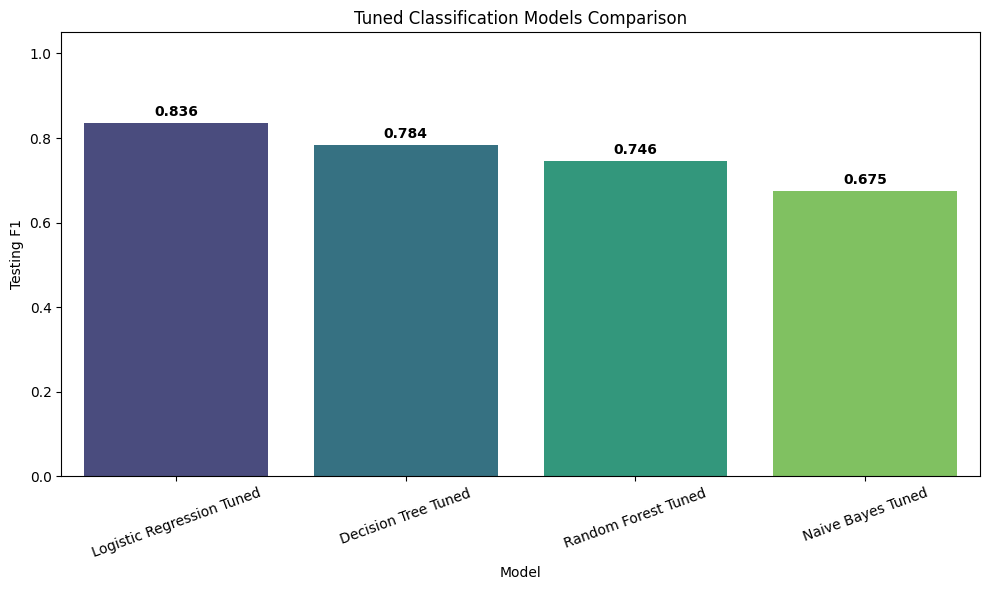

In [70]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="Model", y="Test F1", data=tuned_results_df, palette="viridis")

for i, f1 in enumerate(tuned_results_df["Test F1"]):
    barplot.text(i, f1 + 0.01, f"{f1:.3f}", ha="center", va="bottom", fontweight="bold")

plt.ylim(0, 1.05)
plt.ylabel("Testing F1")
plt.xlabel("Model")
plt.title("Tuned Classification Models Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [71]:
train_pred_best = best_cv_model.bestModel.transform(train_df)
test_pred_best = best_cv_model.bestModel.transform(test_df)

train_acc_best = evaluator_acc.evaluate(train_pred_best)
test_acc_best = evaluator_acc.evaluate(test_pred_best)

train_f1_best = evaluator_f1.evaluate(train_pred_best)
test_f1_best = evaluator_f1.evaluate(test_pred_best)

print("=== Best Tuned Classification Model Metrics ===")
print("Best model:", best_model_name)
print(f"Training Accuracy: {train_acc_best:.4f}")
print(f"Testing Accuracy : {test_acc_best:.4f}")
print(f"Training F1      : {train_f1_best:.4f}")
print(f"Testing F1       : {test_f1_best:.4f}")

=== Best Tuned Classification Model Metrics ===
Best model: Logistic Regression Tuned
Training Accuracy: 0.8363
Testing Accuracy : 0.8375
Training F1      : 0.8343
Testing F1       : 0.8355


In [81]:
baseline_best_f1 = results_df["F1"].max()
baseline_best_model = results_df.loc[results_df["F1"].idxmax(), "Model"]

comparison_df = pd.DataFrame({
    "Version": ["Best Baseline", "Best Tuned"],
    "Model": [baseline_best_model, best_model_name],
    "F1": [baseline_best_f1, best_result["test_f1"]]
})

display(comparison_df)

,Version,Model,F1
0,Best Baseline,Logistic Regression,0.835519
1,Best Tuned,Logistic Regression Tuned,0.835519


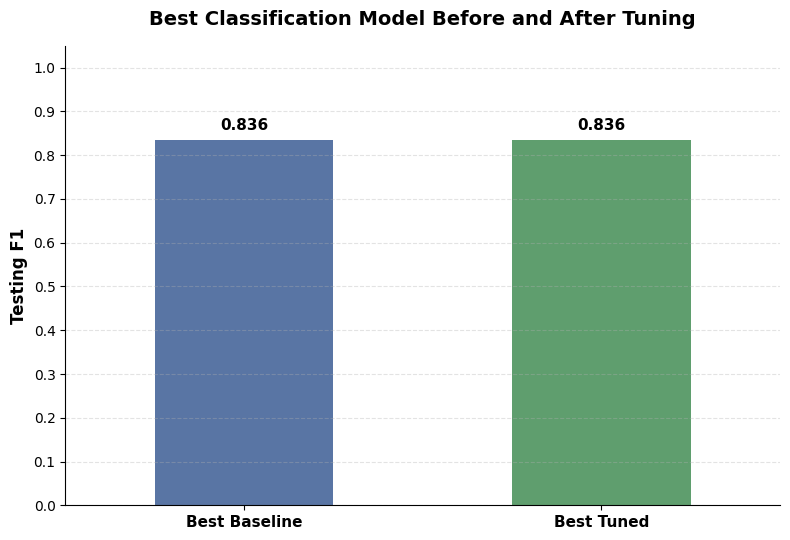

In [73]:
plt.figure(figsize=(8, 5.5))
barplot = sns.barplot(
    x="Version",
    y="F1",
    data=comparison_df,
    palette=["#4C72B0", "#55A868"],
    width=0.5
)

for i, f1 in enumerate(comparison_df["F1"]):
    barplot.text(
        i,
        f1 + 0.015,
        f"{f1:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11
    )

plt.ylim(0, 1.05)
plt.ylabel("Testing F1", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.title("Best Classification Model Before and After Tuning", fontsize=14, fontweight="bold", pad=15)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=10)
plt.xticks(fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

In [80]:
if best_model_name in ["Decision Tree Tuned", "Random Forest Tuned"]:
    best_stage = best_cv_model.bestModel.stages[-1]
    best_transformed = best_cv_model.bestModel.transform(train_df)

    feature_metadata = best_transformed.schema["features"].metadata["ml_attr"]["attrs"]

    feature_names = []
    for attr_type in feature_metadata:
        feature_names.extend([attr["name"] for attr in feature_metadata[attr_type]])

    importance = best_stage.featureImportances.toArray()

    df_best_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values(by="importance", ascending=False)

    top_best_features = df_best_imp.head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_best_features, x="importance", y="feature", palette="viridis")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(top_best_features)

else:
    print(f"Feature importance plot is not available for {best_model_name}.")

Feature importance plot is not available for Logistic Regression Tuned.


In [75]:
diff_f1_best = train_f1_best - test_f1_best

if diff_f1_best > 0.05:
    verdict_best = "⚠️ Overfitting"
elif test_f1_best < 0.7:
    verdict_best = "⚠️ Underfitting"
else:
    verdict_best = "✅ Well-balanced"

print("\nModel verdict:", verdict_best)


Model verdict: ✅ Well-balanced


In [82]:
save_path = "logistic_regression_demand_level_model"

# remove old saved folder
if os.path.exists(save_path):
    shutil.rmtree(save_path)

# save Spark model
best_cv_model.bestModel.write().overwrite().save(save_path)

print("Model saved to:", save_path)
print("Model folder exists?", os.path.exists(save_path))

# zip folder
zip_file = shutil.make_archive(save_path, "zip", save_path)

print("Zip file created:", zip_file)
print("Zip file exists?", os.path.exists(zip_file))

Model saved to: logistic_regression_demand_level_model
Model folder exists? True
Zip file created: /content/logistic_regression_demand_level_model.zip
Zip file exists? True


In [83]:
files.download(zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
best_predictions = best_cv_model.bestModel.transform(test_df)

In [85]:
from pyspark.sql import functions as F

# labels learned by StringIndexer
labels = best_cv_model.bestModel.stages[0].labels

# create mapping from prediction number -> original class name
mapping_expr = F.create_map(
    *[x for i, label in enumerate(labels) for x in (F.lit(float(i)), F.lit(label))]
)

best_predictions_readable = best_predictions.withColumn(
    "predicted_demand_level",
    mapping_expr[F.col("prediction")]
)

best_predictions_readable.select(
    "demand_level",
    "predicted_demand_level",
    "probability"
).show(30, truncate=False)

print("Predicted outputs:")
best_predictions_readable.groupBy("predicted_demand_level").count().show()

print("True outputs:")
best_predictions_readable.groupBy("demand_level").count().show()

+------------+----------------------+----------------------------------------------------------------+
|demand_level|predicted_demand_level|probability                                                     |
+------------+----------------------+----------------------------------------------------------------+
|Medium      |Medium                |[0.9046565193182892,7.554704809672034E-4,0.09458801020074367]   |
|Medium      |Medium                |[0.9721158342360124,0.0024207849297726747,0.025463380834214806] |
|Medium      |High                  |[0.35762685722282783,2.376387875492669E-5,0.6423493788984171]   |
|High        |High                  |[0.0419159772339961,2.833045872796584E-7,0.9580837394614166]    |
|Medium      |Medium                |[0.9614601749141136,0.036369255825030644,0.0021705692608557994] |
|Medium      |Medium                |[0.9593139719368351,9.787810180951746E-4,0.039707247045069824]  |
|High        |High                  |[0.00393491652018687,3.3525285004001